C:\Users\Hp\AppData\Local\Temp\ipykernel_5952\643074079.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


Historical Start Price (2020-10-31): $10.1
One Year Forecast Price (2025-09-30): $12.45


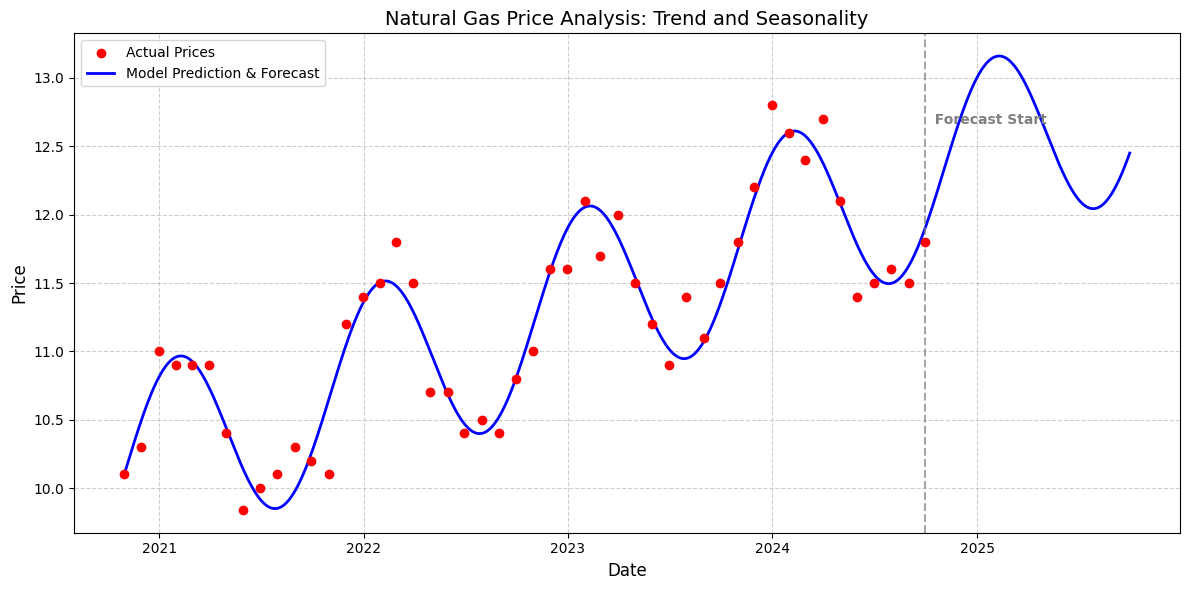

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import datetime

# 1. Load and prepare the data
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'])
start_date = df['Dates'].min()

# Convert dates to number of days from the start for mathematical modeling
df['Days'] = (df['Dates'] - start_date).dt.days

# 2. Define the Model
# We use a Linear Trend (A*t + B) + Sine Wave (C * sin(freq*t + D)) 
# to capture seasonality.
def model_func(t, A, B, C, D):
    # period is 365.25 days for annual seasonality
    return A * t + B + C * np.sin(2 * np.pi * t / 365.25 + D)

# 3. Fit the model to historical data
# p0 is an initial guess for [slope, intercept, amplitude, phase]
params, _ = curve_fit(model_func, df['Days'], df['Prices'], p0=[0.001, 10, 1, 0])

def get_price(input_date):
    """
    Returns an estimated price for any given date.
    input_date: string 'YYYY-MM-DD' or datetime object
    """
    if isinstance(input_date, str):
        input_date = pd.to_datetime(input_date)
    
    days = (input_date - start_date).days
    price = model_func(days, *params)
    return round(price, 2)

# 4. Visualization and Extrapolation
# Generate a range of dates for the plot (Historical + 1 Year Future)
end_date = df['Dates'].max()
forecast_end = end_date + pd.DateOffset(years=1)
vis_dates = pd.date_range(start=start_date, end=forecast_end, freq='D')
vis_days = (vis_dates - start_date).days
vis_prices = model_func(vis_days, *params)

plt.figure(figsize=(12, 6))

# Plot actual historical data points
plt.scatter(df['Dates'], df['Prices'], color='red', label='Actual Prices', zorder=5)

# Plot the continuous model (Trend + Seasonality)
plt.plot(vis_dates, vis_prices, label='Model Prediction & Forecast', color='blue', linewidth=2)

# Add a vertical line to mark where the forecast begins
plt.axvline(x=end_date, color='grey', linestyle='--', alpha=0.7)
plt.text(end_date, plt.ylim()[1]*0.95, '  Forecast Start', color='grey', fontweight='bold')

plt.title('Natural Gas Price Analysis: Trend and Seasonality', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('nat_gas_forecast.png')

# Example output
print(f"Historical Start Price ({start_date.date()}): ${get_price(start_date)}")
print(f"One Year Forecast Price ({forecast_end.date()}): ${get_price(forecast_end)}")